# Author Verification using Support Vector Machine

This notebook demonstrates the complete workflow of the author verification model using SVM.

The implementation is modularized into three main files:
1. `data_prepare.py`
2. `grid_search.py`
3. `final_evaluation.py`


## 1. Import Required Libraries

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Import functions from source code
from data_prepare import process_and_save_data
from grid_search import custom_grid_search
from final_evaluation import train_manual_params


## 2. Data Preparation

This stage performs:
- Loading data from `.csv` file
- Author-based train/test splitting
- Pairs generation for test set
- Saving processed datasets into `.npz` files


In [ ]:
for i in range(5):
    t = i + 19
    process_and_save_data(
        csv_path = '../data/LesswrongLarge.csv',
        output_path = f'../data/processed_data_seed_{t}.npz',
        seed = t
)

print("Data preparation completed.")

Processing Seed: 19...
Saved: ../data/processed_data_seed_19.npz

Processing Seed: 20...
Saved: ../data/processed_data_seed_20.npz

Processing Seed: 21...
Saved: ../data/processed_data_seed_21.npz

Processing Seed: 22...
Saved: ../data/processed_data_seed_22.npz

Processing Seed: 23...
Saved: ../data/processed_data_seed_23.npz

Data preparation completed.


## 3. Hyperparameter Optimization

This stage performs:
- Author-based 5-Fold Cross Validation
- Grid Search over different values of:
  - `C` : {0.1, 1, 10}
  - `gamma`: {0.001, 0.01, 0.1}
- Grid Search was repeated across five random seeds (Seeds 19 to 23).

In [5]:
for i in range(5):
        t = i + 19
        seed_path = f'../data/processed_data_seed_{t}.npz'
        
        random.seed(t)
        np.random.seed(t)
        
        custom_grid_search(seed_path)

print("Grid search completed.")

----------------------Seed: ../data/processed_data_seed_19.npz----------------------

[GRID SEARCH]

{'C': 0.1, 'gamma': 0.001}
  + Fold 1: Val Acc = 0.7233
  + Fold 2: Val Acc = 0.7146
  + Fold 3: Val Acc = 0.7492
  + Fold 4: Val Acc = 0.7430
  + Fold 5: Val Acc = 0.7110
=> {'C': 0.1, 'gamma': 0.001} | Train Mean: 0.7640 | Val Mean: 0.7282



{'C': 0.1, 'gamma': 0.01}
  + Fold 1: Val Acc = 0.5871
  + Fold 2: Val Acc = 0.5908
  + Fold 3: Val Acc = 0.6842
  + Fold 4: Val Acc = 0.6290
  + Fold 5: Val Acc = 0.5985
=> {'C': 0.1, 'gamma': 0.01} | Train Mean: 0.6934 | Val Mean: 0.6179



{'C': 0.1, 'gamma': 0.1}
  + Fold 1: Val Acc = 0.5000
  + Fold 2: Val Acc = 0.5000
  + Fold 3: Val Acc = 0.5000
  + Fold 4: Val Acc = 0.5000
  + Fold 5: Val Acc = 0.5000
=> {'C': 0.1, 'gamma': 0.1} | Train Mean: 1.0000 | Val Mean: 0.5000



{'C': 1, 'gamma': 0.001}
  + Fold 1: Val Acc = 0.7200
  + Fold 2: Val Acc = 0.6904
  + Fold 3: Val Acc = 0.7917
  + Fold 4: Val Acc = 0.7875
  + Fold 5: Val Acc = 0.7205


## 4. Final Model Evaluation

The final SVM model is retrained using the complete training set with `C`: 0.1 and `gamma`: 0.001 and evaluated on unseen authors.

To improve robustness, the entire pipeline is repeated across five random seeds (Seeds 19 to 23).


File: ../data/processed_data_seed_19.npz | C = 0.1, gamma = 0.001

INFORMATION:
               precision    recall  f1-score   support

Different (0)       0.75      0.73      0.74      1400
     Same (1)       0.74      0.76      0.75      1400

     accuracy                           0.74      2800
    macro avg       0.74      0.74      0.74      2800
 weighted avg       0.74      0.74      0.74      2800

Confusion Matrix:
[[1017  383]
 [ 334 1066]]
-> Accuracy: 0.7439
-> ROC-AUC : 0.8234
-------------------------------------------

File: ../data/processed_data_seed_20.npz | C = 0.1, gamma = 0.001

INFORMATION:
               precision    recall  f1-score   support

Different (0)       0.73      0.75      0.74      1400
     Same (1)       0.74      0.72      0.73      1400

     accuracy                           0.73      2800
    macro avg       0.74      0.73      0.73      2800
 weighted avg       0.74      0.73      0.73      2800

Confusion Matrix:
[[1045  355]
 [ 387 1013]]

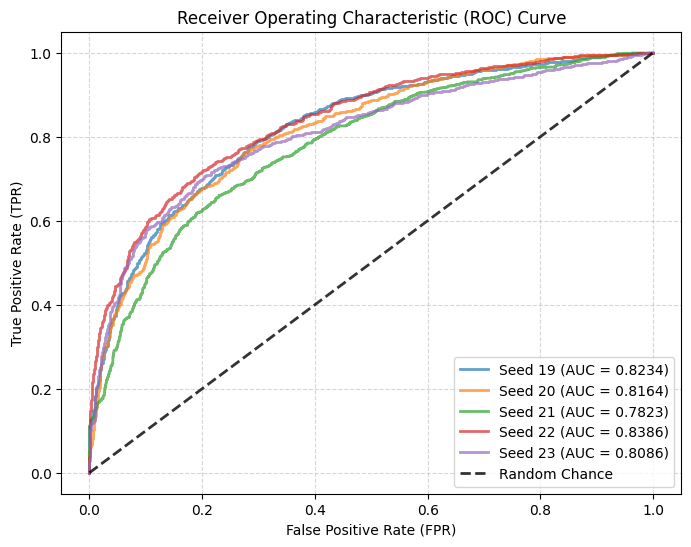

In [3]:
test_accuracies = []
test_aucs = []
    
plt.figure(figsize=(8, 6))
    
for i in range(5):
    t = i + 19

    seed_path = f'../data/processed_data_seed_{t}.npz'
        
    random.seed(t)
    np.random.seed(t)

    acc, auc, fpr, tpr = train_manual_params(seed_path, c=0.1, gamma=0.001)
        
    test_accuracies.append(acc)
    test_aucs.append(auc)
        
    # ROC curve
    plt.plot(fpr, tpr, lw=2, alpha=0.7, label=f'Seed {t} (AUC = {auc:.4f})')
        
print("RESULT\n")
print(f"Mean Accuracy: {np.mean(test_accuracies):.4f} ± {np.std(test_accuracies):.4f}")
print(f"Mean ROC-AUC: {np.mean(test_aucs):.4f} ± {np.std(test_aucs):.4f}")
    
# Setting for ROC curve
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='black', label='Random Chance', alpha=0.8)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
    
plt.show()

## 5. Conclusion

The SVM model demonstrates:
- Stable performance across multiple random seeds
- Balanced classification behavior
- Strong discriminative capability for author verification

The use of author-based splitting and repeated evaluation improves the reliability and generalization capability of the model.
